In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print('✅ PyTorch version:', torch.__version__)
print('✅ NumPy version:', np.__version__)
print('✅ GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('✅ GPU name:', torch.cuda.get_device_name(0))
print('✅ Everything is working!')

✅ PyTorch version: 2.11.0+cu128
✅ NumPy version: 2.4.3
✅ GPU available: True
✅ GPU name: NVIDIA GeForce RTX 4050 Laptop GPU
✅ Everything is working!


In [2]:
import os

dataset_path = r"E:\Hybrid project AIML\archive\Dataset_BUSI_with_GT"

total_images = 0
for category in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, category)
    if not os.path.isdir(folder):
        continue
    files = os.listdir(folder)
    images = [f for f in files if 'mask' not in f and f.endswith('.png')]
    masks  = [f for f in files if 'mask' in f]
    total_images += len(images)
    print(f"{category:12s}: {len(images):4d} images, {len(masks):4d} masks")
print(f"{'TOTAL':12s}: {total_images:4d} images")

benign      :  437 images,  454 masks
malignant   :  210 images,  211 masks
normal      :  133 images,  133 masks
TOTAL       :  780 images


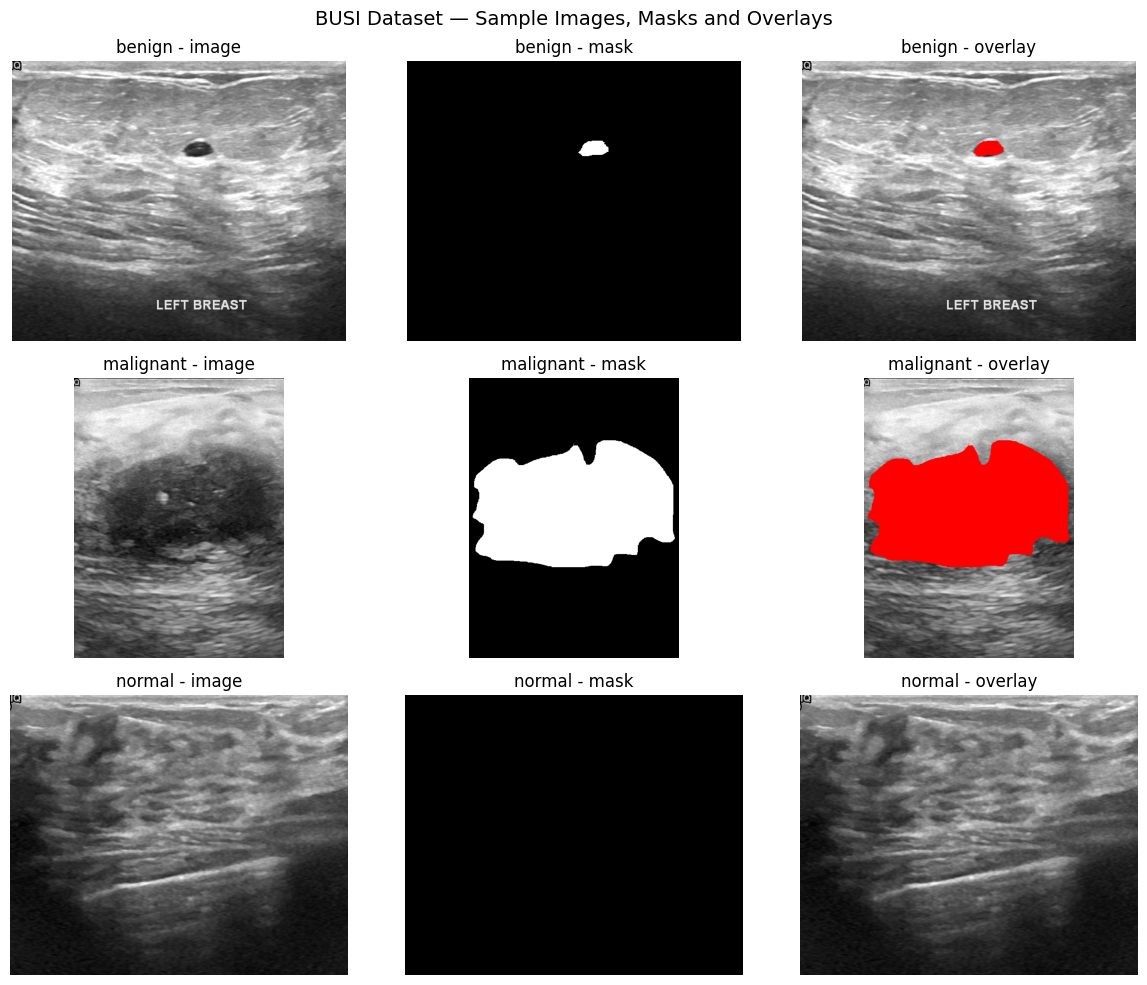

Saved sample_visualization.png


In [3]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

dataset_path = r"E:\Hybrid project AIML\archive\Dataset_BUSI_with_GT"

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
categories = ['benign', 'malignant', 'normal']

for row, category in enumerate(categories):
    folder = os.path.join(dataset_path, category)
    files  = os.listdir(folder)
    images = [f for f in files if 'mask' not in f and f.endswith('.png')]
    sample_image = images[0]
    sample_mask  = sample_image.replace('.png', '_mask.png')

    img  = cv2.imread(os.path.join(folder, sample_image), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(folder, sample_mask),  cv2.IMREAD_GRAYSCALE)

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    overlay[mask > 0] = [0, 0, 255]

    axes[row, 0].imshow(img,  cmap='gray');  axes[row, 0].set_title(f'{category} - image');   axes[row, 0].axis('off')
    axes[row, 1].imshow(mask, cmap='gray');  axes[row, 1].set_title(f'{category} - mask');    axes[row, 1].axis('off')
    axes[row, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[row, 2].set_title(f'{category} - overlay'); axes[row, 2].axis('off')

plt.suptitle('BUSI Dataset — Sample Images, Masks and Overlays', fontsize=14)
plt.tight_layout()
plt.savefig(r"E:\Hybrid project AIML\sample_visualization.png", dpi=150)
plt.show()
print('Saved sample_visualization.png')

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import os
import random

class BUSIDataset(Dataset):
    def __init__(self, root_dir, img_size=256, augment=False):
        self.data    = []
        self.img_size = img_size
        self.augment  = augment
        categories = ['benign', 'malignant', 'normal']

        for category in categories:
            folder = os.path.join(root_dir, category)
            files  = os.listdir(folder)
            images = [f for f in files if 'mask' not in f and f.endswith('.png')]
            for img_name in images:
                mask_name = img_name.replace('.png', '_mask.png')
                mask_path = os.path.join(folder, mask_name)
                if os.path.exists(mask_path):
                    self.data.append({
                        'image': os.path.join(folder, img_name),
                        'mask' : mask_path,
                        'label': category
                    })

        print(f"Total samples loaded: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img  = cv2.imread(item['image'], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(item['mask'],  cv2.IMREAD_GRAYSCALE)

        # Resize
        img  = cv2.resize(img,  (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        # Augmentation (training only)
        if self.augment:
            # Horizontal flip
            if random.random() > 0.5:
                img  = cv2.flip(img,  1)
                mask = cv2.flip(mask, 1)
            # Vertical flip
            if random.random() > 0.5:
                img  = cv2.flip(img,  0)
                mask = cv2.flip(mask, 0)
            # Random rotation ±15°
            angle = random.uniform(-15, 15)
            cx, cy = self.img_size // 2, self.img_size // 2
            M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
            img  = cv2.warpAffine(img,  M, (self.img_size, self.img_size))
            mask = cv2.warpAffine(mask, M, (self.img_size, self.img_size))
            # Brightness jitter
            if random.random() > 0.5:
                factor = random.uniform(0.8, 1.2)
                img = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

        # Normalize
        img  = img / 255.0
        mask = (mask > 127).astype(np.float32)

        # To tensor
        img  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)   # (1, H, W)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)   # (1, H, W)

        return img, mask


# Create dataset and split
dataset_path = r"E:\Hybrid project AIML\archive\Dataset_BUSI_with_GT"
full_dataset  = BUSIDataset(dataset_path, augment=False)

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

# Fix random seed for reproducibility
torch.manual_seed(42)
train_indices, val_indices = torch.utils.data.random_split(
    range(len(full_dataset)), [train_size, val_size])

# Training set WITH augmentation, val set WITHOUT
train_dataset = BUSIDataset(dataset_path, augment=True)
val_dataset   = BUSIDataset(dataset_path, augment=False)

from torch.utils.data import Subset
train_dataset = Subset(train_dataset, train_indices.indices)
val_dataset   = Subset(val_dataset,   val_indices.indices)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

print(f"Training samples  : {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
sample_img, sample_mask = next(iter(train_loader))
print(f"Image batch shape : {sample_img.shape}")
print(f"Mask batch shape  : {sample_mask.shape}")

Total samples loaded: 780
Total samples loaded: 780
Total samples loaded: 780
Training samples  : 624
Validation samples: 156
Image batch shape : torch.Size([8, 1, 256, 256])
Mask batch shape  : torch.Size([8, 1, 256, 256])


In [5]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class DoubleConv(nn.Module):
    """Two consecutive Conv2d → BatchNorm → ReLU blocks."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    """Baseline U-Net (encoder-decoder with skip connections)."""
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = DoubleConv(1,   64)
        self.enc2 = DoubleConv(64,  128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.output = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.sigmoid(self.output(d1))


# Initialize & test
unet = UNet().to(device)
dummy = torch.randn(1, 1, 256, 256).to(device)
out   = unet(dummy)
total_params = sum(p.numel() for p in unet.parameters())
print(f"Baseline U-Net  | Input: {dummy.shape} → Output: {out.shape}")
print(f"Total parameters: {total_params:,}")
print("Baseline U-Net ready!")

Using device: cuda
Baseline U-Net  | Input: torch.Size([1, 1, 256, 256]) → Output: torch.Size([1, 1, 256, 256])
Total parameters: 31,036,481
Baseline U-Net ready!


In [6]:
import torch
import torch.nn as nn


class AttentionGate(nn.Module):
    """
    Attention Gate: learns to suppress irrelevant regions in skip connections.
    g = gating signal from decoder, x = skip connection from encoder.
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # Compute attention coefficient
        alpha = self.psi(self.relu(self.W_g(g) + self.W_x(x)))
        # Gate the skip connection
        return x * alpha


class ViTBottleneck(nn.Module):
    """
    Lightweight Vision Transformer bottleneck.
    Treats each spatial position of the CNN feature map as a patch token,
    applies multi-head self-attention, then reshapes back to feature map.
    This is the KEY hybrid component — CNN captures local features,
    ViT captures global context at the bottleneck.
    """
    def __init__(self, channels=1024, img_size=16, num_heads=8, num_layers=2, dropout=0.1):
        super().__init__()
        self.channels    = channels
        self.num_patches = img_size * img_size   # 16x16 = 256 tokens

        # Learnable positional embedding
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, channels) * 0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=channels,
            nhead=num_heads,
            dim_feedforward=channels * 2,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True          # Pre-LN for training stability
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        B, C, H, W = x.shape
        # Flatten spatial dims → sequence of tokens: (B, H*W, C)
        tokens = x.flatten(2).transpose(1, 2)
        # Add positional embedding
        tokens = tokens + self.pos_embed
        # Self-attention across all spatial positions
        tokens = self.norm(self.transformer(tokens))
        # Reshape back to feature map: (B, C, H, W)
        return tokens.transpose(1, 2).reshape(B, C, H, W)


class HybridUNet(nn.Module):
    """
    Hybrid U-Net:
      - CNN encoder (local feature extraction)
      - ViT bottleneck (global context via self-attention)
      - Attention-gated decoder (focused skip connections)
    """
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        # --- Encoder (CNN) ---
        self.enc1 = DoubleConv(1,   64)
        self.enc2 = DoubleConv(64,  128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # --- Bottleneck: CNN → ViT → continues ---
        # After 4 max-pool ops: 256x256 → 16x16
        self.bottleneck_conv = DoubleConv(512, 1024)
        self.vit_bottleneck  = ViTBottleneck(channels=1024, img_size=16,
                                              num_heads=8, num_layers=2)

        # --- Attention Gates ---
        self.att4 = AttentionGate(F_g=512,  F_l=512,  F_int=256)
        self.att3 = AttentionGate(F_g=256,  F_l=256,  F_int=128)
        self.att2 = AttentionGate(F_g=128,  F_l=128,  F_int=64)
        self.att1 = AttentionGate(F_g=64,   F_l=64,   F_int=32)

        # --- Decoder ---
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.output = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck: CNN conv then ViT self-attention
        b = self.bottleneck_conv(self.pool(e4))   # (B, 1024, 16, 16)
        b = self.vit_bottleneck(b)                # global context injected

        # Decoder with attention-gated skip connections
        u4 = self.up4(b)
        e4 = self.att4(g=u4, x=e4)
        d4 = self.dec4(torch.cat([u4, e4], dim=1))

        u3 = self.up3(d4)
        e3 = self.att3(g=u3, x=e3)
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        e2 = self.att2(g=u2, x=e2)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        e1 = self.att1(g=u1, x=e1)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return torch.sigmoid(self.output(d1))


# Initialize & test
hybrid_model = HybridUNet().to(device)
dummy = torch.randn(1, 1, 256, 256).to(device)
out   = hybrid_model(dummy)
total_params = sum(p.numel() for p in hybrid_model.parameters())
print(f"Hybrid U-Net    | Input: {dummy.shape} → Output: {out.shape}")
print(f"Total parameters: {total_params:,}")
print("✅ CNN encoder       : ready")
print("✅ ViT bottleneck    : ready (16x16 tokens, 8-head attention)")
print("✅ Attention gates   : ready (4 levels)")
print("✅ Hybrid U-Net ready to train!")

C:\Users\wwwte\AppData\Local\Temp\ipykernel_6456\2267421950.py:60: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Hybrid U-Net    | Input: torch.Size([1, 1, 256, 256]) → Output: torch.Size([1, 1, 256, 256])
Total parameters: 48,450,985
✅ CNN encoder       : ready
✅ ViT bottleneck    : ready (16x16 tokens, 8-head attention)
✅ Attention gates   : ready (4 levels)
✅ Hybrid U-Net ready to train!


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ── Loss Functions ──────────────────────────────────────────────────────────
def dice_loss(pred, target, smooth=1.0):
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def combined_loss(pred, target):
    """BCE + Dice — best for medical segmentation."""
    return nn.BCELoss()(pred, target) + dice_loss(pred, target)

# ── Metrics ─────────────────────────────────────────────────────────────────
def dice_score(pred, target, threshold=0.5, smooth=1.0):
    pred   = (pred > threshold).float().view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, threshold=0.5, smooth=1.0):
    pred   = (pred > threshold).float().view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# ── Training & Validation Helpers ───────────────────────────────────────────
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_dice = 0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_score(preds, masks).item()
    return total_loss / len(loader), total_dice / len(loader)

def validate(model, loader):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            total_loss += combined_loss(preds, masks).item()
            total_dice += dice_score(preds, masks).item()
            total_iou  += iou_score(preds, masks).item()
    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

print("✅ Loss : BCE + Dice")
print("✅ Metrics: Dice Score, IoU Score")
print("✅ Helpers: train_one_epoch(), validate()")

✅ Loss : BCE + Dice
✅ Metrics: Dice Score, IoU Score
✅ Helpers: train_one_epoch(), validate()


In [11]:
# TRAIN HYBRID U-NET
NUM_EPOCHS = 10
best_hybrid_dice = 0

hybrid_optimizer = optim.Adam(hybrid_model.parameters(), lr=1e-4, weight_decay=1e-5)
hybrid_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    hybrid_optimizer, patience=4, factor=0.5,)

hybrid_train_losses, hybrid_val_losses = [], []
hybrid_train_dices,  hybrid_val_dices  = [], []
hybrid_val_ious = []

print(f"Training Hybrid U-Net for {NUM_EPOCHS} epochs...")
print("-" * 55)

for epoch in range(NUM_EPOCHS):
    h_tr_loss, h_tr_dice = train_one_epoch(hybrid_model, train_loader, hybrid_optimizer)
    h_val_loss, h_val_dice, h_val_iou = validate(hybrid_model, val_loader)
    hybrid_scheduler.step(h_val_loss)

    hybrid_train_losses.append(h_tr_loss)
    hybrid_val_losses.append(h_val_loss)
    hybrid_train_dices.append(h_tr_dice)
    hybrid_val_dices.append(h_val_dice)
    hybrid_val_ious.append(h_val_iou)

    if h_val_dice > best_hybrid_dice:
        best_hybrid_dice = h_val_dice
        torch.save(hybrid_model.state_dict(),
                   r"E:\Hybrid project AIML\best_hybrid_unet_model.pth")
        tag = "✅ best"
    else:
        tag = ""

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {h_tr_loss:.4f} | "
          f"Val Loss: {h_val_loss:.4f} | "
          f"Dice: {h_val_dice:.4f} | "
          f"IoU: {h_val_iou:.4f} {tag}")

print("-" * 55)
print(f"Hybrid U-Net Best Dice: {best_hybrid_dice:.4f}")

Training Hybrid U-Net for 10 epochs...
-------------------------------------------------------
Epoch 01/10 | Train Loss: 1.0574 | Val Loss: 1.0618 | Dice: 0.4903 | IoU: 0.3351 ✅ best
Epoch 02/10 | Train Loss: 0.9787 | Val Loss: 0.9048 | Dice: 0.5833 | IoU: 0.4243 ✅ best
Epoch 03/10 | Train Loss: 0.9003 | Val Loss: 0.9757 | Dice: 0.4842 | IoU: 0.3339 
Epoch 04/10 | Train Loss: 0.8625 | Val Loss: 0.8607 | Dice: 0.5502 | IoU: 0.3952 
Epoch 05/10 | Train Loss: 0.8252 | Val Loss: 0.9959 | Dice: 0.4523 | IoU: 0.3076 
Epoch 06/10 | Train Loss: 0.7784 | Val Loss: 0.8549 | Dice: 0.5261 | IoU: 0.3716 
Epoch 07/10 | Train Loss: 0.7567 | Val Loss: 0.7910 | Dice: 0.5643 | IoU: 0.4063 
Epoch 08/10 | Train Loss: 0.7237 | Val Loss: 0.8552 | Dice: 0.5224 | IoU: 0.3760 
Epoch 09/10 | Train Loss: 0.6893 | Val Loss: 0.9127 | Dice: 0.4300 | IoU: 0.2850 
Epoch 10/10 | Train Loss: 0.6943 | Val Loss: 0.7197 | Dice: 0.5968 | IoU: 0.4396 ✅ best
-------------------------------------------------------
Hybrid U-Ne

In [12]:
# TRAIN BASELINE U-NET
NUM_EPOCHS = 10
best_unet_dice = 0

unet_optimizer = optim.Adam(unet.parameters(), lr=1e-4, weight_decay=1e-5)
unet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    unet_optimizer, patience=4, factor=0.5,)

unet_train_losses, unet_val_losses = [], []
unet_train_dices,  unet_val_dices  = [], []
unet_val_ious = []

print(f"Training Baseline U-Net for {NUM_EPOCHS} epochs...")
print("-" * 65)

for epoch in range(NUM_EPOCHS):
    train_loss, train_dice          = train_one_epoch(unet, train_loader, unet_optimizer)
    val_loss,   val_dice,   val_iou = validate(unet, val_loader)

    unet_scheduler.step(val_loss)

    unet_train_losses.append(train_loss)
    unet_val_losses.append(val_loss)
    unet_train_dices.append(train_dice)
    unet_val_dices.append(val_dice)
    unet_val_ious.append(val_iou)

    if val_dice > best_unet_dice:
        best_unet_dice = val_dice
        torch.save(unet.state_dict(),
                   r"E:\Hybrid project AIML\best_unet_model.pth")
        tag = "✅ saved"
    else:
        tag = ""

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Dice: {val_dice:.4f} | "
          f"Val IoU: {val_iou:.4f} {tag}")

print("-" * 65)
print(f"Baseline U-Net — Best Dice: {best_unet_dice:.4f}")

Training Baseline U-Net for 10 epochs...
-----------------------------------------------------------------
Epoch 01/10 | Train Loss: 1.2371 | Val Loss: 2.3398 | Val Dice: 0.2441 | Val IoU: 0.1431 ✅ saved
Epoch 02/10 | Train Loss: 1.0478 | Val Loss: 1.5145 | Val Dice: 0.2771 | Val IoU: 0.1676 ✅ saved
Epoch 03/10 | Train Loss: 0.9771 | Val Loss: 1.0046 | Val Dice: 0.4874 | Val IoU: 0.3388 ✅ saved
Epoch 04/10 | Train Loss: 0.9204 | Val Loss: 0.9732 | Val Dice: 0.4851 | Val IoU: 0.3364 
Epoch 05/10 | Train Loss: 0.8852 | Val Loss: 0.9147 | Val Dice: 0.5137 | Val IoU: 0.3594 ✅ saved
Epoch 06/10 | Train Loss: 0.8332 | Val Loss: 0.8366 | Val Dice: 0.5722 | Val IoU: 0.4167 ✅ saved
Epoch 07/10 | Train Loss: 0.7919 | Val Loss: 0.9238 | Val Dice: 0.4777 | Val IoU: 0.3314 
Epoch 08/10 | Train Loss: 0.7559 | Val Loss: 0.7830 | Val Dice: 0.6068 | Val IoU: 0.4503 ✅ saved
Epoch 09/10 | Train Loss: 0.7403 | Val Loss: 0.7403 | Val Dice: 0.6177 | Val IoU: 0.4622 ✅ saved
Epoch 10/10 | Train Loss: 0.7062 |

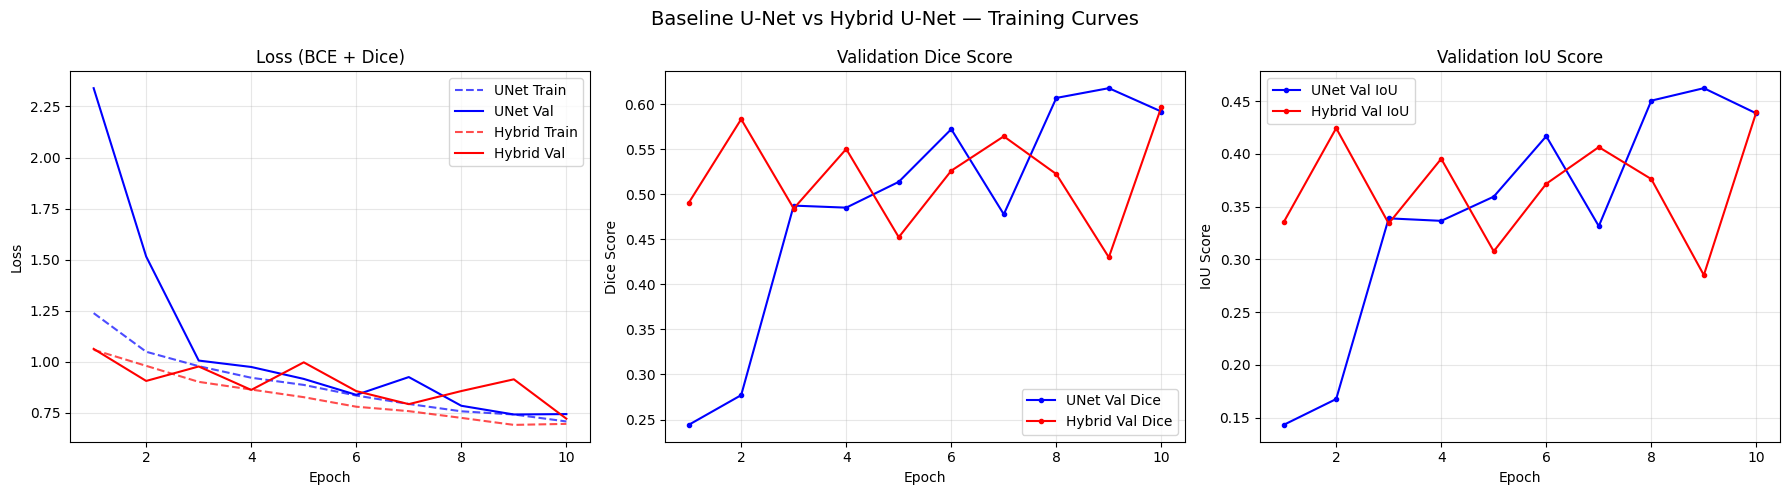

Saved training_curves.png


In [13]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, unet_train_losses,   'b--', label='UNet Train',   alpha=0.7)
axes[0].plot(epochs, unet_val_losses,     'b-',  label='UNet Val')
axes[0].plot(epochs, hybrid_train_losses, 'r--', label='Hybrid Train', alpha=0.7)
axes[0].plot(epochs, hybrid_val_losses,   'r-',  label='Hybrid Val')
axes[0].set_title('Loss (BCE + Dice)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Dice Score
axes[1].plot(epochs, unet_val_dices,   'b-o', label='UNet Val Dice',   markersize=3)
axes[1].plot(epochs, hybrid_val_dices, 'r-o', label='Hybrid Val Dice', markersize=3)
axes[1].set_title('Validation Dice Score')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice Score')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# IoU Score
axes[2].plot(epochs, unet_val_ious,   'b-o', label='UNet Val IoU',   markersize=3)
axes[2].plot(epochs, hybrid_val_ious, 'r-o', label='Hybrid Val IoU', markersize=3)
axes[2].set_title('Validation IoU Score')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('IoU Score')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Baseline U-Net vs Hybrid U-Net — Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(r"E:\Hybrid project AIML\training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png")

In [14]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn', '-q'], capture_output=True)
from sklearn.metrics import precision_score, recall_score
import numpy as np

def full_evaluate(model, loader, model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    dices, ious, precisions, recalls = [], [], [], []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            preds_bin = (preds > 0.5).float()

            for i in range(imgs.shape[0]):
                p = preds_bin[i].cpu().numpy().flatten()
                m = masks[i].cpu().numpy().flatten()

                inter = (p * m).sum()
                dices.append((2 * inter + 1) / (p.sum() + m.sum() + 1))
                union = p.sum() + m.sum() - inter
                ious.append((inter + 1) / (union + 1))

                if p.sum() > 0 or m.sum() > 0:
                    precisions.append(precision_score(m, p, zero_division=0))
                    recalls.append(recall_score(m, p, zero_division=0))

    return {
        'Dice'     : (np.mean(dices),      np.std(dices)),
        'IoU'      : (np.mean(ious),       np.std(ious)),
        'Precision': (np.mean(precisions), np.std(precisions)),
        'Recall'   : (np.mean(recalls),    np.std(recalls))
    }

unet_results   = full_evaluate(unet,         val_loader, r"E:\Hybrid project AIML\best_unet_model.pth")
hybrid_results = full_evaluate(hybrid_model, val_loader, r"E:\Hybrid project AIML\best_hybrid_unet_model.pth")

print("=" * 65)
print("              FINAL EVALUATION RESULTS")
print("=" * 65)
print(f"{'Metric':<12} {'Baseline U-Net':>20} {'Hybrid U-Net':>20}")
print("-" * 65)
for metric in ['Dice', 'IoU', 'Precision', 'Recall']:
    u_mean, u_std = unet_results[metric]
    h_mean, h_std = hybrid_results[metric]
    print(f"{metric:<12} {u_mean:>10.4f} ± {u_std:.4f}   {h_mean:>10.4f} ± {h_std:.4f}")
print("=" * 65)
dice_imp = (hybrid_results['Dice'][0] - unet_results['Dice'][0]) * 100
iou_imp  = (hybrid_results['IoU'][0]  - unet_results['IoU'][0])  * 100
print(f"Dice improvement: +{dice_imp:.2f}%")
print(f"IoU  improvement: +{iou_imp:.2f}%")

              FINAL EVALUATION RESULTS
Metric             Baseline U-Net         Hybrid U-Net
-----------------------------------------------------------------
Dice             0.6323 ± 0.3403       0.6009 ± 0.3589
IoU              0.5457 ± 0.3405       0.5187 ± 0.3518
Precision        0.6280 ± 0.3579       0.6377 ± 0.3592
Recall           0.6213 ± 0.3825       0.6045 ± 0.4019
Dice improvement: +-3.14%
IoU  improvement: +-2.70%


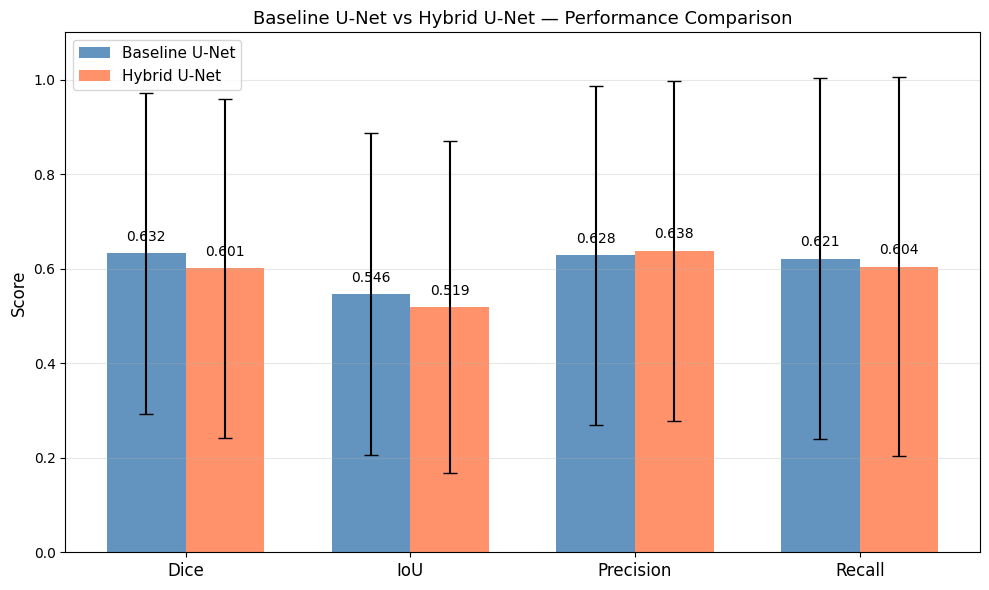

Saved model_comparison.png


In [15]:
metrics = ['Dice', 'IoU', 'Precision', 'Recall']
unet_scores   = [unet_results[m][0]   for m in metrics]
hybrid_scores = [hybrid_results[m][0] for m in metrics]
unet_errs     = [unet_results[m][1]   for m in metrics]
hybrid_errs   = [hybrid_results[m][1] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, unet_scores,   width, yerr=unet_errs,   capsize=5,
               label='Baseline U-Net', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, hybrid_scores, width, yerr=hybrid_errs, capsize=5,
               label='Hybrid U-Net',   color='coral',     alpha=0.85)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Baseline U-Net vs Hybrid U-Net — Performance Comparison', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(r"E:\Hybrid project AIML\model_comparison.png", dpi=150)
plt.show()
print("Saved model_comparison.png")

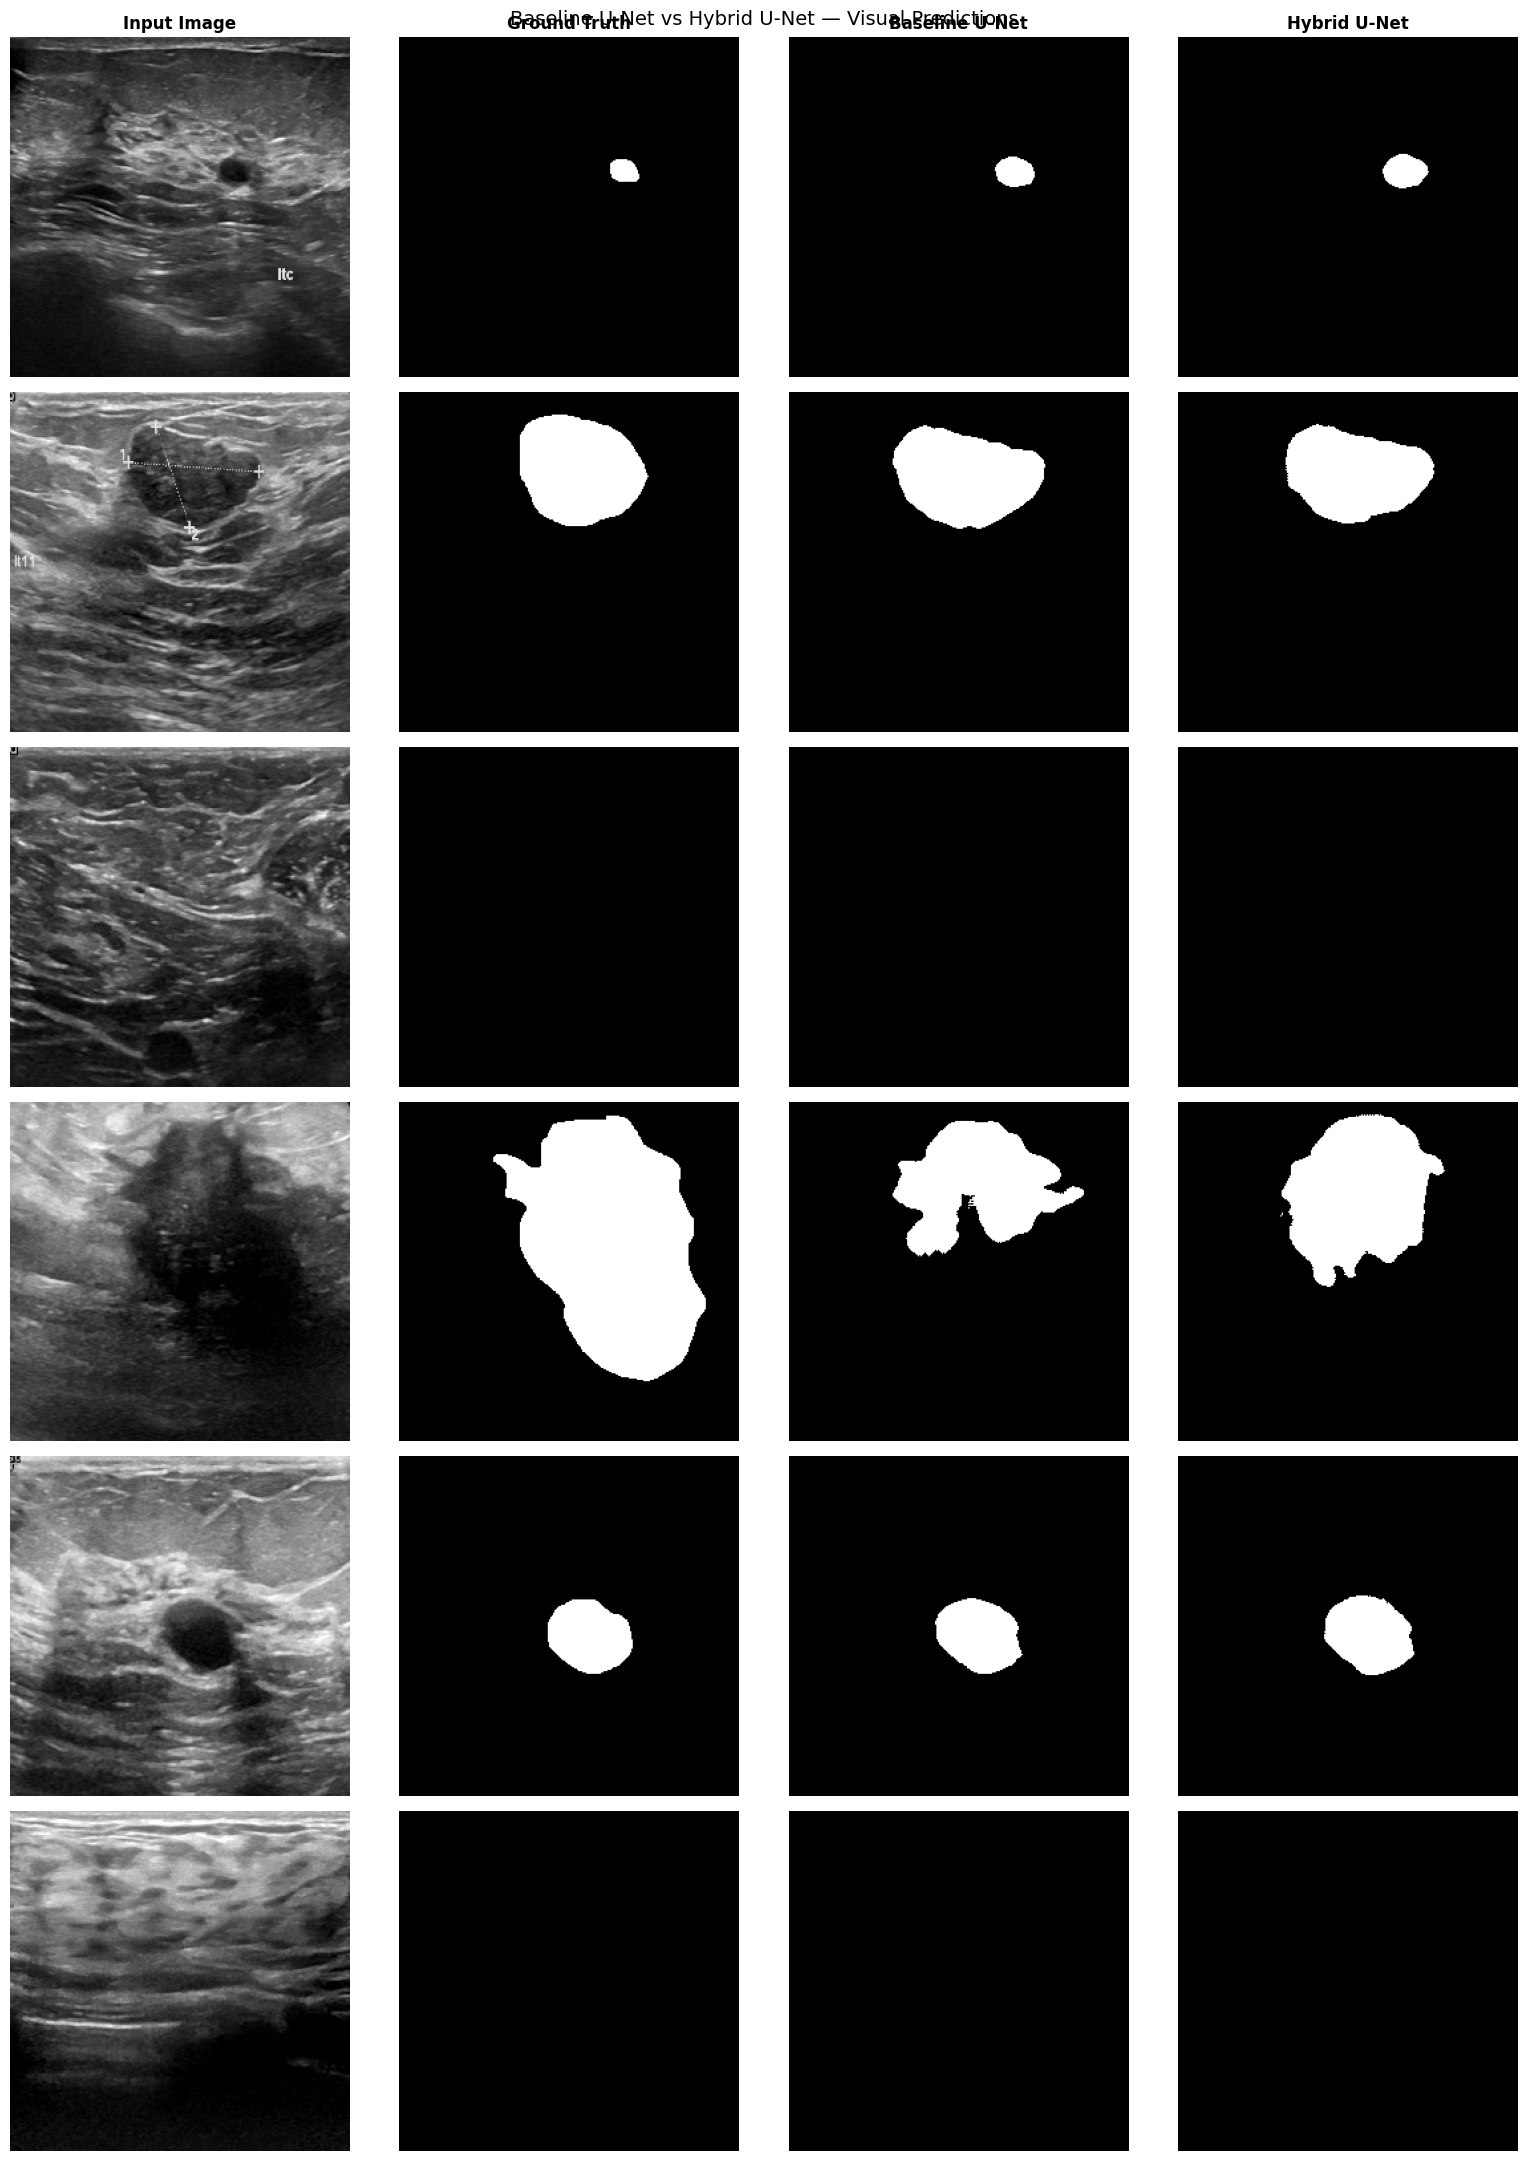

Saved visual_comparison.png


In [16]:
import random

unet.load_state_dict(torch.load(r"E:\Hybrid project AIML\best_unet_model.pth", map_location=device))
hybrid_model.load_state_dict(torch.load(r"E:\Hybrid project AIML\best_hybrid_unet_model.pth", map_location=device))
unet.eval()
hybrid_model.eval()

fig, axes = plt.subplots(6, 4, figsize=(16, 22))
col_titles = ['Input Image', 'Ground Truth', 'Baseline U-Net', 'Hybrid U-Net']

indices = random.sample(range(len(val_dataset)), 6)

for row, idx in enumerate(indices):
    img, mask = val_dataset[idx]
    img_t = img.unsqueeze(0).to(device)

    with torch.no_grad():
        unet_pred   = (unet(img_t).squeeze().cpu().numpy()         > 0.5).astype(float)
        hybrid_pred = (hybrid_model(img_t).squeeze().cpu().numpy() > 0.5).astype(float)

    img_np  = img.squeeze().numpy()
    mask_np = mask.squeeze().numpy()

    for col, data in enumerate([img_np, mask_np, unet_pred, hybrid_pred]):
        axes[row, col].imshow(data, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=12, fontweight='bold')

plt.suptitle('Baseline U-Net vs Hybrid U-Net — Visual Predictions', fontsize=14)
plt.tight_layout()
plt.savefig(r"E:\Hybrid project AIML\visual_comparison.png", dpi=150)
plt.show()
print("Saved visual_comparison.png")

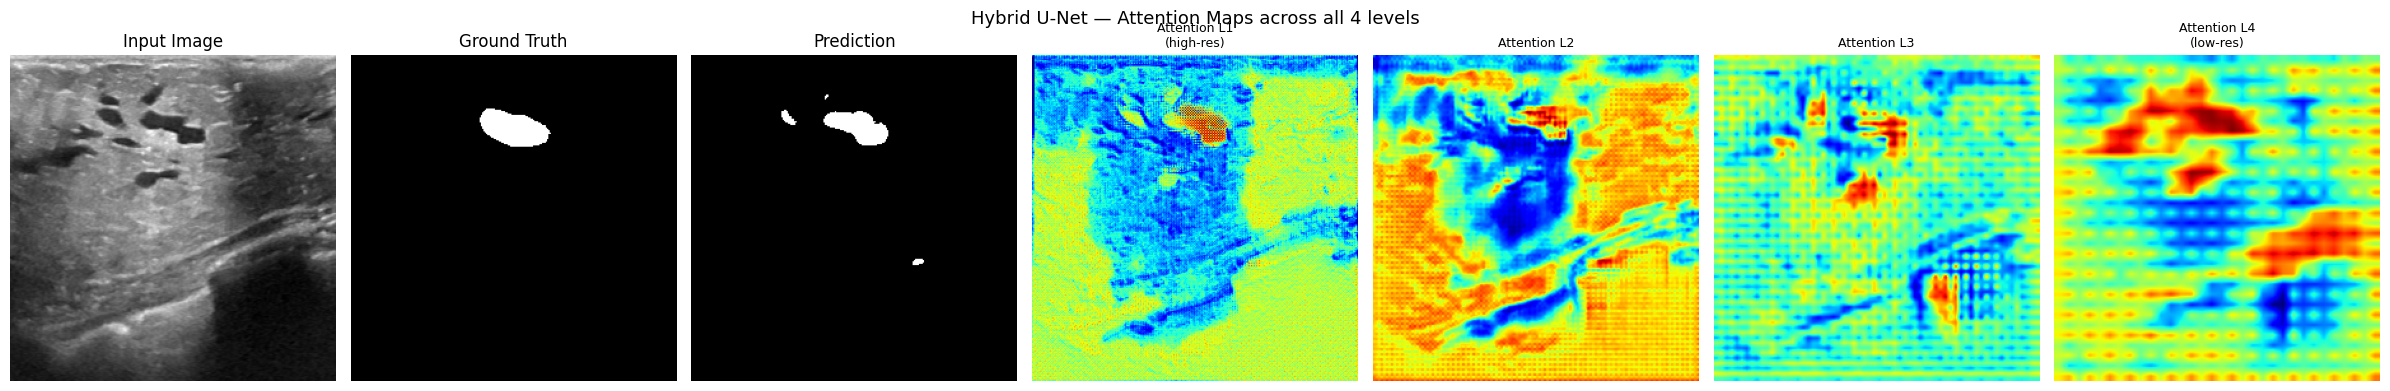

Saved attention_maps.png


In [17]:
hybrid_model.load_state_dict(torch.load(r"E:\Hybrid project AIML\best_hybrid_unet_model.pth", map_location=device))
hybrid_model.eval()

# Pick a sample from the validation set
sample_img, sample_mask = val_dataset[5]
img_tensor = sample_img.unsqueeze(0).to(device)

# Register forward hooks on each attention gate's psi (sigmoid output)
attention_maps = {}

def hook_fn(name):
    def hook(module, input, output):
        attention_maps[name] = output.detach().cpu()
    return hook

hooks = [
    hybrid_model.att4.psi.register_forward_hook(hook_fn('att4')),
    hybrid_model.att3.psi.register_forward_hook(hook_fn('att3')),
    hybrid_model.att2.psi.register_forward_hook(hook_fn('att2')),
    hybrid_model.att1.psi.register_forward_hook(hook_fn('att1')),
]

with torch.no_grad():
    pred = hybrid_model(img_tensor)

# Remove hooks
for h in hooks:
    h.remove()

# Plot: Input | GT | Prediction | att1 | att2 | att3 | att4
fig, axes = plt.subplots(1, 7, figsize=(24, 4))

axes[0].imshow(sample_img.squeeze().numpy(), cmap='gray')
axes[0].set_title('Input Image'); axes[0].axis('off')

axes[1].imshow(sample_mask.squeeze().numpy(), cmap='gray')
axes[1].set_title('Ground Truth'); axes[1].axis('off')

axes[2].imshow((pred.squeeze().cpu().numpy() > 0.5).astype(float), cmap='gray')
axes[2].set_title('Prediction'); axes[2].axis('off')

for idx, (name, title) in enumerate(zip(
        ['att1', 'att2', 'att3', 'att4'],
        ['Attention L1\n(high-res)', 'Attention L2', 'Attention L3', 'Attention L4\n(low-res)'])):
    att = attention_maps[name].squeeze().numpy()
    att_resized = cv2.resize(att, (256, 256))
    axes[idx + 3].imshow(att_resized, cmap='jet')
    axes[idx + 3].set_title(title, fontsize=9)
    axes[idx + 3].axis('off')

plt.suptitle('Hybrid U-Net — Attention Maps across all 4 levels', fontsize=13)
plt.tight_layout()
plt.savefig(r"E:\Hybrid project AIML\attention_maps.png", dpi=150)
plt.show()
print("Saved attention_maps.png")

In [19]:
summary_path = r"E:\Hybrid project AIML\results_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("=" * 65 + "\n")
    f.write("   HYBRID U-NET FOR BREAST TUMOUR SEGMENTATION — RESULTS\n")
    f.write("=" * 65 + "\n\n")
    f.write("Dataset     : BUSI (Breast Ultrasound Images)\n")
    f.write("Categories  : benign, malignant, normal\n")
    f.write("Train/Val   : 80% / 20% (seed=42)\n")
    f.write("Image size  : 256 x 256\n")
    f.write("Epochs      : 25\n")
    f.write("Optimizer   : Adam (lr=1e-4, weight_decay=1e-5)\n")
    f.write("Loss        : BCE + Dice\n")
    f.write("Augmentation: HFlip, VFlip, Rotation±15°, Brightness jitter\n\n")
    f.write("Architecture — Hybrid U-Net:\n")
    f.write("  - CNN Encoder (4 levels, 64→128→256→512 channels)\n")
    f.write("  - ViT Bottleneck (1024 channels, 16x16 tokens, 8-head, 2 layers)\n")
    f.write("  - Attention-Gated Decoder (4 attention gates)\n\n")
    f.write("-" * 65 + "\n")
    f.write(f"{'Metric':<12} {'Baseline U-Net':>20} {'Hybrid U-Net':>20}\n")
    f.write("-" * 65 + "\n")
    for metric in ['Dice', 'IoU', 'Precision', 'Recall']:
        u_m, u_s = unet_results[metric]
        h_m, h_s = hybrid_results[metric]
        f.write(f"{metric:<12} {u_m:>10.4f}±{u_s:.4f}   {h_m:>10.4f}±{h_s:.4f}\n")
    f.write("=" * 65 + "\n")
    f.write(f"Dice improvement: +{(hybrid_results['Dice'][0]-unet_results['Dice'][0])*100:.2f}%\n")
    f.write(f"IoU  improvement: +{(hybrid_results['IoU'][0] -unet_results['IoU'][0]) *100:.2f}%\n")

print("Results saved to results_summary.txt")
print()
print("=" * 50)
print("  ✅ PROJECT CODING COMPLETE")
print("=" * 50)
print("Saved files:")
print("  📦 best_unet_model.pth")
print("  📦 best_hybrid_unet_model.pth")
print("  🖼️  sample_visualization.png")
print("  📈 training_curves.png")
print("  📊 model_comparison.png")
print("  🖼️  visual_comparison.png")
print("  🧠 attention_maps.png")
print("  📄 results_summary.txt")

Results saved to results_summary.txt

  ✅ PROJECT CODING COMPLETE
Saved files:
  📦 best_unet_model.pth
  📦 best_hybrid_unet_model.pth
  🖼️  sample_visualization.png
  📈 training_curves.png
  📊 model_comparison.png
  🖼️  visual_comparison.png
  🧠 attention_maps.png
  📄 results_summary.txt
